In [2]:
import os

os.environ["MLFLOW_TRACKING_USERNAME"] = "giomamaca"
os.environ["MLFLOW_TRACKING_PASSWORD"] = "ac4daccf465eeaa2602d8c203c082911f4d4de3c"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score, train_test_split, KFold
from sklearn.feature_selection import VarianceThreshold, RFE, SelectKBest, f_regression, SelectFromModel
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb
import xgboost as xgb


import mlflow
import mlflow.sklearn

RANDOM_STATE = 42

mlflow.set_tracking_uri("https://dagshub.com/giomamaca/GitTest.mlflow")
mlflow.set_experiment("house_prices1")

<Experiment: artifact_location='mlflow-artifacts:/b98d828cc65b42bd83edf6afb1cdced2', creation_time=1775305529981, experiment_id='1', last_update_time=1775305529981, lifecycle_stage='active', name='house_prices1', tags={'mlflow.experimentKind': 'custom_model_development'}, workspace='default'>

In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
kaggle_test_raw = test.copy()

In [4]:
train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [5]:
test

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal



#### FEATURE ENGINEERING


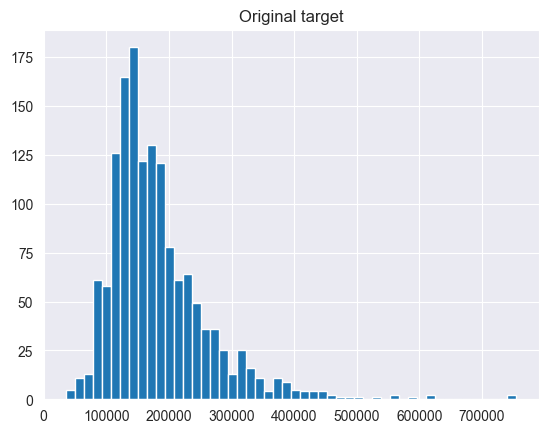

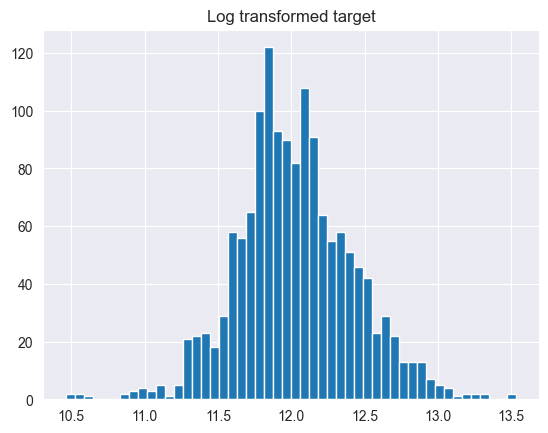

In [6]:
y = np.log1p(train["SalePrice"])
X = train.drop(columns=["Id","SalePrice"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

plt.hist(train["SalePrice"], bins=50)
plt.title("Original target")
plt.show()

plt.hist(y, bins=50)
plt.title("Log transformed target")
plt.show()


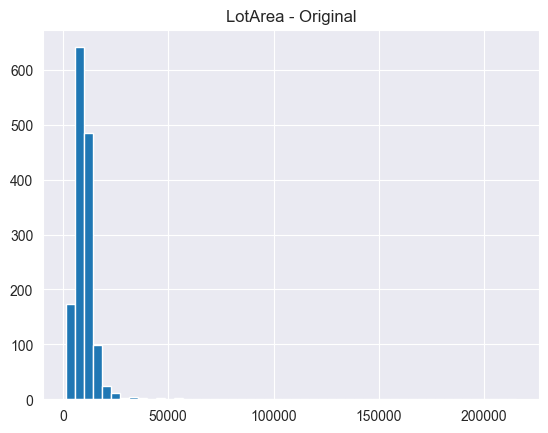

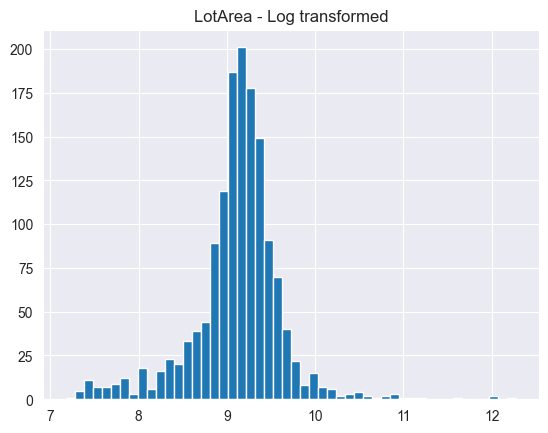

In [7]:
plt.hist(train["LotArea"], bins=50)
plt.title("LotArea - Original")
plt.show()

plt.hist(np.log1p(train["LotArea"]), bins=50)
plt.title("LotArea - Log transformed")
plt.show()

In [8]:
cat_cols = [col for col in X_train.columns if X_train[col].dtype == 'object']
num_cols = [col for col in X_train.columns if X_train[col].dtype != 'object']
print (cat_cols)
print(num_cols)

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'Enclos

In [9]:
for col in cat_cols:
    X_train[col] = X_train[col].fillna("None")
    X_test[col] = X_test[col].fillna("None")

for col in num_cols:
    X_train[col] = X_train[col].fillna(0)
    X_test[col] = X_test[col].fillna(0)

In [10]:
for col in X_train.select_dtypes(include = np.number).columns:
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    X_test[col] = X_test[col].fillna(median)
for col in X_train.select_dtypes(include="object").columns:
    mode = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode)
    X_test[col] = X_test[col].fillna(mode)

In [42]:
for df in [X_train, X_test]:
    df["TotalSF"]      = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
    df["HouseAge"]     = df["YrSold"] - df["YearBuilt"]
    df["HasGarage"]    = np.where(df["GarageArea"].values > 0, 1, 0)
    df["HasBsmt"]      = np.where(df["TotalBsmtSF"].values > 0, 1, 0)
    df["TotalBath"]    = df["FullBath"] + 0.5 * df["HalfBath"] + df["BsmtFullBath"] + 0.5 * df["BsmtHalfBath"]
    df["TotalPorchSF"] = df["OpenPorchSF"] + df["EnclosedPorch"] + df["3SsnPorch"] + df["ScreenPorch"]
    df["IsRemodeled"]  = np.where(df["YearRemodAdd"] != df["YearBuilt"], 1, 0)
    df["QualCond"]     = df["OverallQual"] * df["OverallCond"]
    df["LotAreaLog"]   = np.log1p(df["LotArea"])

ntrain = X_train.shape[0]

all_data = pd.concat([X_train, X_test], axis=0)
all_data = pd.get_dummies(all_data, drop_first=True)

X_train = all_data.iloc[:ntrain, :].copy()
X_test  = all_data.iloc[ntrain:, :].copy()
print(X_train.shape)
print(X_test.shape)


(1168, 273)
(292, 273)


##### FEATURE SELECTION

In [43]:
# --- VarianceThreshold ---
vt = VarianceThreshold(0.01)
X_vt = vt.fit_transform(X_train)
X_test_vt = vt.transform(X_test)

# --- SelectKBest ---
skb = SelectKBest(score_func=f_regression, k=100)
X_skb = skb.fit_transform(X_train, y_train)
X_test_skb = skb.transform(X_test)

# --- RFE ---
rfe = RFE(LinearRegression(), n_features_to_select=80)
X_rfe = rfe.fit_transform(X_train, y_train)
X_test_rfe = rfe.transform(X_test)

# --- VT + RFE ---
rfe2 = RFE(LinearRegression(), n_features_to_select=80)
X_vt_rfe = rfe2.fit_transform(X_vt, y_train)
X_test_vt_rfe = rfe2.transform(X_test_vt)

# --- RandomForest selection ---
rf_selector_model = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)
rf_selector_model.fit(X_train, y_train)
rf_selector = SelectFromModel(rf_selector_model, threshold="median")
X_rfsel = rf_selector.fit_transform(X_train, y_train)
X_test_rfsel = rf_selector.transform(X_test)

# --- Lasso selection ---
lasso_selector_model = Lasso(alpha=0.0005, random_state=RANDOM_STATE, max_iter=10000)
lasso_selector = SelectFromModel(lasso_selector_model)
X_lasso = lasso_selector.fit_transform(X_train, y_train)
X_test_lasso = lasso_selector.transform(X_test)

# --- Optional scaling ---
scaler = StandardScaler()
X_train_lasso_sc = scaler.fit_transform(X_lasso)
X_test_lasso_sc  = scaler.transform(X_test_lasso)

X_train_vtrfe_sc = scaler.fit_transform(X_vt_rfe)
X_test_vtrfe_sc  = scaler.transform(X_test_vt_rfe)

# --- XGBoost selection ---
xgb_selector_model = xgb.XGBRegressor(n_estimators=300, random_state=RANDOM_STATE, verbosity=0)
xgb_selector = SelectFromModel(xgb_selector_model, threshold="median")
X_xgbsel = xgb_selector.fit_transform(X_train, y_train)
X_test_xgbsel = xgb_selector.transform(X_test)

# --- XGBoost + RFE ---
rfe3 = RFE(LinearRegression(), n_features_to_select=80)
X_xgb_rfe = rfe3.fit_transform(X_xgbsel, y_train)
X_test_xgb_rfe = rfe3.transform(X_test_xgbsel)

print("XGB selection:", X_xgbsel.shape)
print("XGB + RFE:", X_xgb_rfe.shape)
# --- Shapes ---
print("Feature Selection Shapes:")
print("Original:", X_train.shape)
print("VT:", X_vt.shape)
print("SKB:", X_skb.shape)
print("RFE:", X_rfe.shape)
print("VT+RFE:", X_vt_rfe.shape)
print("RF:", X_rfsel.shape)
print("Lasso:", X_lasso.shape)

C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.290e-01, tolerance: 1.781e-02
  model = cd_fast.enet_coordinate_descent(


XGB selection: (1168, 137)
XGB + RFE: (1168, 80)
Feature Selection Shapes:
Original: (1168, 273)
VT: (1168, 198)
SKB: (1168, 100)
RFE: (1168, 80)
VT+RFE: (1168, 80)
RF: (1168, 137)
Lasso: (1168, 117)


##### MLFLOW

In [13]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_rmse(model, X, y):
    scores = -cross_val_score(model, X, y,
                              scoring="neg_root_mean_squared_error",
                              cv=kf)
    return scores.mean(), scores.std()

##### EXPERIMENTS

In [14]:
def run_and_log_regression(model, X_tr, y_tr, X_te, y_te, run_name, fs_name):
    with mlflow.start_run(run_name=run_name):
        model.fit(X_tr, y_tr)
        train_pred = model.predict(X_tr)
        train_rmse = np.sqrt(mean_squared_error(y_tr, train_pred))

        cv_mean, cv_std = cv_rmse(model, X_tr, y_tr)

        test_pred = model.predict(X_te)
        test_rmse = np.sqrt(mean_squared_error(y_te, test_pred))

        mlflow.log_param("model", model.__class__.__name__)
        mlflow.log_param("feature_selection", fs_name)
        mlflow.log_param("n_features", X_tr.shape[1])

        mlflow.log_metric("rmse_train", train_rmse)
        mlflow.log_metric("rmse_cv_mean", cv_mean)
        mlflow.log_metric("rmse_cv_std", cv_std)
        mlflow.log_metric("rmse_test", test_rmse)

        mlflow.sklearn.log_model(model, "model")

        print(f"{run_name} logged")

In [15]:
run_and_log_regression(
    LinearRegression(),
    X_train, y_train, X_test, y_test,
    "LR_None", "None"
)

2026/04/13 11:56:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 11:56:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LR_None logged
🏃 View run LR_None at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/b1f1c61908df4324ab14b42bb098c521
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


In [44]:
run_and_log_regression(
    LinearRegression(),
    X_vt, y_train, X_test_vt, y_test,
    "LR_VT", "VarianceThreshold"
)

2026/04/13 12:17:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:17:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LR_VT logged
🏃 View run LR_VT at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/0e0677b6ebce4269aef4ba169b2e13c0
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


In [17]:
run_and_log_regression(
    LinearRegression(),
    X_skb, y_train, X_test_skb, y_test,
    "LR_SKB", "SelectKBest"
)

2026/04/13 11:57:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 11:57:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LR_SKB logged
🏃 View run LR_SKB at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/68c284efc0eb4a2eafeb8512a3c711eb
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


In [18]:
run_and_log_regression(
    LinearRegression(),
    X_rfe, y_train, X_test_rfe, y_test,
    "LR_RFE", "RFE"
)

2026/04/13 11:57:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 11:58:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LR_RFE logged
🏃 View run LR_RFE at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/87d57ac7c81641dd84bb6f3ffdbe6187
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


In [19]:
run_and_log_regression(
    LinearRegression(),
    X_vt_rfe, y_train, X_test_vt_rfe, y_test,
    "LR_VT_RFE", "VT+RFE"
)

2026/04/13 11:58:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 11:58:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LR_VT_RFE logged
🏃 View run LR_VT_RFE at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/4ee284d33d64406daed67e82c98aa01f
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


In [20]:
run_and_log_regression(
    LinearRegression(),
    X_rfsel, y_train, X_test_rfsel, y_test,
    "LR_RFSEL", "RF_selection"
)

2026/04/13 11:58:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 11:58:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LR_RFSEL logged
🏃 View run LR_RFSEL at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/babc5e4e83d348d7bbe368d17a705136
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


In [21]:
run_and_log_regression(
    LinearRegression(),
    X_lasso, y_train, X_test_lasso, y_test,
    "LR_LASSOSEL", "Lasso_selection"
)

2026/04/13 11:59:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 11:59:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LR_LASSOSEL logged
🏃 View run LR_LASSOSEL at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/5103026f94054344b34eb67d24741538
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


In [22]:
run_and_log_regression(
    RandomForestRegressor(n_estimators=300, max_depth=8, random_state=RANDOM_STATE),
    X_train, y_train, X_test, y_test,
    "RF_None", "None"
)

2026/04/13 11:59:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 11:59:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RF_None logged
🏃 View run RF_None at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/28153c81fe3c4634a9442a1d9caee6de
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


In [23]:
run_and_log_regression(
    RandomForestRegressor(n_estimators=300, max_depth=8, random_state=RANDOM_STATE),
    X_vt_rfe, y_train, X_test_vt_rfe, y_test,
    "RF_VT_RFE", "VT+RFE"
)

2026/04/13 12:00:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:00:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RF_VT_RFE logged
🏃 View run RF_VT_RFE at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/b91dd5c4bf8d4c4694a5b2ac7f6d4273
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


In [24]:
run_and_log_regression(
    RandomForestRegressor(n_estimators=300, max_depth=8, random_state=RANDOM_STATE),
    X_rfsel, y_train, X_test_rfsel, y_test,
    "RF_RFSEL", "RF_selection"
)

2026/04/13 12:01:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:01:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RF_RFSEL logged
🏃 View run RF_RFSEL at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/cc6a154966434847ad280e1c2911c30e
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


In [25]:
run_and_log_regression(
    ElasticNet(alpha=0.0005, l1_ratio=0.5, max_iter=10000),
    X_vt_rfe, y_train, X_test_vt_rfe, y_test,
    "Elastic_VT_RFE", "VT+RFE"
)

C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.773e+00, tolerance: 1.781e-02
  model = cd_fast.enet_coordinate_descent(
C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.043e+00, tolerance: 1.395e-02
  model = cd_fast.enet_coordinate_descent(
C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisati

Elastic_VT_RFE logged
🏃 View run Elastic_VT_RFE at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/065b1a20747645f2ab68405144c9c654
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


In [26]:
run_and_log_regression(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    X_vt_rfe, y_train, X_test_vt_rfe, y_test,
    "GBR_VT_RFE", "VT+RFE"
)

2026/04/13 12:01:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:02:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


GBR_VT_RFE logged
🏃 View run GBR_VT_RFE at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/80bddf82b0f0484f9bf1dae08dabb44b
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


In [27]:
run_and_log_regression(
    xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4,
                     subsample=0.8, colsample_bytree=0.8,
                     random_state=RANDOM_STATE, verbosity=0),
    X_train, y_train, X_test, y_test,
    "XGB_None", "None"
)

2026/04/13 12:02:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:02:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB_None logged
🏃 View run XGB_None at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/df8a3e6c6b87445fa5f21cf1ba6d6450
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


In [28]:
run_and_log_regression(
    xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4,
                     subsample=0.8, colsample_bytree=0.8,
                     random_state=RANDOM_STATE, verbosity=0),
    X_vt, y_train, X_test_vt, y_test,
    "XGB_VT", "VarianceThreshold"
)

2026/04/13 12:02:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:02:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB_VT logged
🏃 View run XGB_VT at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/0190a535d27243da96b92e036095d528
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


In [29]:
run_and_log_regression(
    xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4,
                     subsample=0.8, colsample_bytree=0.8,
                     random_state=RANDOM_STATE, verbosity=0),
    X_vt_rfe, y_train, X_test_vt_rfe, y_test,
    "XGB_VT_RFE", "VT+RFE"
)

2026/04/13 12:03:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:03:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB_VT_RFE logged
🏃 View run XGB_VT_RFE at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/594561f1009340d2a24ee0c7a53ac30d
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


In [30]:
run_and_log_regression(
    xgb.XGBRegressor(n_estimators=100, learning_rate=0.3, max_depth=8,
                     random_state=RANDOM_STATE, verbosity=0),
    X_vt_rfe, y_train, X_test_vt_rfe, y_test,
    "XGB_overfit_demo", "VT+RFE"
)

2026/04/13 12:03:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:03:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB_overfit_demo logged
🏃 View run XGB_overfit_demo at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/3a2f620ed3754125a3783dbbc8b04573
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


In [31]:
run_and_log_regression(
    xgb.XGBRegressor(n_estimators=50, learning_rate=0.5, max_depth=2,
                     random_state=RANDOM_STATE, verbosity=0),
    X_vt_rfe, y_train, X_test_vt_rfe, y_test,
    "XGB_underfit_demo", "VT+RFE"
)

2026/04/13 12:04:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:04:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB_underfit_demo logged
🏃 View run XGB_underfit_demo at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/6885a2a21b584a2b86912724a4e28e57
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


In [32]:
run_and_log_regression(
    xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4,
                     subsample=0.8, colsample_bytree=0.8,
                     random_state=RANDOM_STATE, verbosity=0),
    X_xgb_rfe, y_train, X_test_xgb_rfe, y_test,
    "XGB_XGBSEL_RFE", "XGB_selection+RFE"
)

2026/04/13 12:04:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:04:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB_XGBSEL_RFE logged
🏃 View run XGB_XGBSEL_RFE at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/605ef085783e49db9c9b1f8113982724
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


In [33]:
xgb_configs = [
    {"n_estimators": 1000, "learning_rate": 0.01, "max_depth": 3, "subsample": 0.8},
    {"n_estimators": 500,  "learning_rate": 0.05, "max_depth": 3, "subsample": 0.7},
    {"n_estimators": 700,  "learning_rate": 0.02, "max_depth": 4, "subsample": 0.9},
    {"n_estimators": 300,  "learning_rate": 0.1,  "max_depth": 3, "subsample": 0.8},
]

for config in xgb_configs:
    run_and_log_regression(
        xgb.XGBRegressor(**config, random_state=RANDOM_STATE, verbosity=0),
        X_vt, y_train, X_test_vt, y_test,
        f"XGB_ne{config['n_estimators']}_lr{config['learning_rate']}_d{config['max_depth']}",
        "VarianceThreshold"
    )

2026/04/13 12:04:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:05:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB_ne1000_lr0.01_d3 logged
🏃 View run XGB_ne1000_lr0.01_d3 at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/352b4c0d49484e76b27885f6edd7158e
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


2026/04/13 12:05:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:05:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB_ne500_lr0.05_d3 logged
🏃 View run XGB_ne500_lr0.05_d3 at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/28e2556cedad49f29bcc60aa37baf553
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


2026/04/13 12:05:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:06:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB_ne700_lr0.02_d4 logged
🏃 View run XGB_ne700_lr0.02_d4 at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/f32dcd89d5a046d48f218df08887a5d2
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


2026/04/13 12:06:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:06:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB_ne300_lr0.1_d3 logged
🏃 View run XGB_ne300_lr0.1_d3 at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/58bfd6632ddb4c04b2b03a60348d11cf
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


In [34]:
lgb_configs = [
    {"n_estimators": 1000, "learning_rate": 0.01, "max_depth": 4, "num_leaves": 31},
    {"n_estimators": 500,  "learning_rate": 0.05, "max_depth": 4, "num_leaves": 31},
    {"n_estimators": 1000, "learning_rate": 0.01, "max_depth": 6, "num_leaves": 63},
    {"n_estimators": 700,  "learning_rate": 0.02, "max_depth": 5, "num_leaves": 50},
    {"n_estimators": 300,  "learning_rate": 0.1,  "max_depth": 3, "num_leaves": 20},
]

for config in lgb_configs:
    run_name = f"LGBM_ne{config['n_estimators']}_lr{config['learning_rate']}_d{config['max_depth']}_nl{config['num_leaves']}"
    run_and_log_regression(
        lgb.LGBMRegressor(**config, random_state=RANDOM_STATE, verbose=-1),
        X_vt, y_train, X_test_vt, y_test,
        run_name, "VarianceThreshold"
    )
    print(f"{run_name} done")

C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature nam

LGBM_ne1000_lr0.01_d4_nl31 logged
🏃 View run LGBM_ne1000_lr0.01_d4_nl31 at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/7eb2154a043147d1ad1e6022ad079979
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1
LGBM_ne1000_lr0.01_d4_nl31 done


C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature nam

LGBM_ne500_lr0.05_d4_nl31 logged
🏃 View run LGBM_ne500_lr0.05_d4_nl31 at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/a09f80a5d0ed4a01991c5e236c72adce
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1
LGBM_ne500_lr0.05_d4_nl31 done


C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature nam

LGBM_ne1000_lr0.01_d6_nl63 logged
🏃 View run LGBM_ne1000_lr0.01_d6_nl63 at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/e60037e424da45208b24eab97000f8bd
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1
LGBM_ne1000_lr0.01_d6_nl63 done


C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature nam

LGBM_ne700_lr0.02_d5_nl50 logged
🏃 View run LGBM_ne700_lr0.02_d5_nl50 at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/6a62b21c42814eb4a6d4211be692fe7c
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1
LGBM_ne700_lr0.02_d5_nl50 done


C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature nam

LGBM_ne300_lr0.1_d3_nl20 logged
🏃 View run LGBM_ne300_lr0.1_d3_nl20 at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/45a4f39643ff467ba9ff7f4920aea0b3
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1
LGBM_ne300_lr0.1_d3_nl20 done


In [35]:
for alpha in [0.01, 0.1, 1, 10, 100]:
    run_and_log_regression(
        Ridge(alpha=alpha),
        X_vt, y_train, X_test_vt, y_test,
        f"Ridge_alpha_{alpha}", "VarianceThreshold"
    )

2026/04/13 12:08:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:09:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge_alpha_0.01 logged
🏃 View run Ridge_alpha_0.01 at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/bde2899de75e4f58916e11e131baf6ae
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


2026/04/13 12:09:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:09:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge_alpha_0.1 logged
🏃 View run Ridge_alpha_0.1 at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/54fcf10188c54a01a1b292b034208aa6
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


2026/04/13 12:09:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:09:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge_alpha_1 logged
🏃 View run Ridge_alpha_1 at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/30d5b56190bf41c59a7604e374b523ea
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


2026/04/13 12:10:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:10:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge_alpha_10 logged
🏃 View run Ridge_alpha_10 at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/2f4addb6c3a24b2790c5ea0bcaa99450
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


2026/04/13 12:10:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:10:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge_alpha_100 logged
🏃 View run Ridge_alpha_100 at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/3ce27146dbeb442c8f27a2fa2d342770
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


In [36]:
for alpha in [0.0001, 0.001, 0.01, 0.1]:
    run_and_log_regression(
        Lasso(alpha=alpha, max_iter=10000),
        X_vt, y_train, X_test_vt, y_test,
        f"Lasso_alpha_{alpha}", "VarianceThreshold"
    )

C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.648e+00, tolerance: 1.781e-02
  model = cd_fast.enet_coordinate_descent(
C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.703e+00, tolerance: 1.395e-02
  model = cd_fast.enet_coordinate_descent(
C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisati

Lasso_alpha_0.0001 logged
🏃 View run Lasso_alpha_0.0001 at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/cd9eee472af849eca51ebf38153d0d02
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.054e-01, tolerance: 1.781e-02
  model = cd_fast.enet_coordinate_descent(
C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.141e-02, tolerance: 1.395e-02
  model = cd_fast.enet_coordinate_descent(
C:\Users\User\miniconda3\envs\cs224n\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisati

Lasso_alpha_0.001 logged
🏃 View run Lasso_alpha_0.001 at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/f8079a20395348c095f55d7f95f33dd7
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


2026/04/13 12:11:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:12:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Lasso_alpha_0.01 logged
🏃 View run Lasso_alpha_0.01 at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/bdd5febb3dbc4a8192864797249382bf
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


2026/04/13 12:12:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:12:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Lasso_alpha_0.1 logged
🏃 View run Lasso_alpha_0.1 at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/c76529b16f1545cb939fafe88d4a305d
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1


In [ ]:
 def run_pipeline_gridsearch(pipeline, param_grid, run_name):
    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=kf,
        scoring='neg_root_mean_squared_error',
        verbose=1,
        n_jobs=-1
    )
    grid.fit(X_train, y_train)

    test_pred = grid.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(grid.best_params_)
        mlflow.log_metric("cv_rmse_mean", -grid.best_score_)
        mlflow.log_metric("rmse_test",    test_rmse)
        mlflow.sklearn.log_model(grid.best_estimator_, "model")

        gap    = test_rmse - (-grid.best_score_)
        status = "Overfit" if gap > 0.05 else "OK"
        print(f"{run_name}: CV={-grid.best_score_:.4f}  Test={test_rmse:.4f}  {status}")
    return -grid.best_score_, test_rmse, grid.best_estimator_

In [ ]:
gridsearch_experiments = [
    (Pipeline([('vt', VarianceThreshold()), ('model', LinearRegression())]),
     {'vt__threshold': [0.001, 0.01, 0.05]},
     "GS_VT_LR"),

    (Pipeline([('vt', VarianceThreshold()), ('skb', SelectKBest(f_regression)), ('model', LinearRegression())]),
     {'vt__threshold': [0.001, 0.01], 'skb__k': [80, 100, 150]},
     "GS_VT_SKB_LR"),

    (Pipeline([('vt', VarianceThreshold()), ('rfe', RFE(LinearRegression())), ('model', LinearRegression())]),
     {'vt__threshold': [0.001, 0.01], 'rfe__n_features_to_select': [50, 80, 100]},
     "GS_VT_RFE_LR"),

    (Pipeline([('vt', VarianceThreshold()), ('model', Ridge())]),
     {'vt__threshold': [0.001, 0.01, 0.05], 'model__alpha': [1, 10, 50, 100]},
     "GS_VT_Ridge"),

    (Pipeline([('vt', VarianceThreshold()), ('skb', SelectKBest(f_regression)), ('model', Ridge())]),
     {'vt__threshold': [0.001, 0.01], 'skb__k': [80, 100, 150], 'model__alpha': [1, 10, 50, 100]},
     "GS_VT_SKB_Ridge"),

    (Pipeline([('vt', VarianceThreshold()), ('rfe', RFE(LinearRegression())), ('model', Ridge())]),
     {'vt__threshold': [0.001, 0.01], 'rfe__n_features_to_select': [50, 80, 100], 'model__alpha': [1, 10, 50]},
     "GS_VT_RFE_Ridge"),

    (Pipeline([('vt', VarianceThreshold()), ('model', Lasso(max_iter=10000))]),
     {'vt__threshold': [0.001, 0.01, 0.05], 'model__alpha': [0.0001, 0.0005, 0.001, 0.01]},
     "GS_VT_Lasso"),

    (Pipeline([('vt', VarianceThreshold()), ('skb', SelectKBest(f_regression)), ('model', Lasso(max_iter=10000))]),
     {'vt__threshold': [0.001, 0.01], 'skb__k': [80, 100, 150], 'model__alpha': [0.0001, 0.0005, 0.001]},
     "GS_VT_SKB_Lasso"),

    (Pipeline([('vt', VarianceThreshold()), ('rfe', RFE(LinearRegression())), ('model', Lasso(max_iter=10000))]),
     {'vt__threshold': [0.001, 0.01], 'rfe__n_features_to_select': [50, 80], 'model__alpha': [0.0001, 0.0005, 0.001]},
     "GS_VT_RFE_Lasso"),

    (Pipeline([('vt', VarianceThreshold()), ('model', xgb.XGBRegressor(random_state=RANDOM_STATE, verbosity=0))]),
     {'vt__threshold': [0.001, 0.01, 0.05], 'model__n_estimators': [500, 1000], 'model__learning_rate': [0.01, 0.05], 'model__max_depth': [3, 4]},
     "GS_VT_XGB"),

    (Pipeline([('vt', VarianceThreshold()), ('skb', SelectKBest(f_regression)), ('model', xgb.XGBRegressor(random_state=RANDOM_STATE, verbosity=0))]),
     {'vt__threshold': [0.001, 0.01], 'skb__k': [80, 100, 150], 'model__n_estimators': [500, 1000], 'model__learning_rate': [0.01, 0.05], 'model__max_depth': [3, 4]},
     "GS_VT_SKB_XGB"),

    (Pipeline([('vt', VarianceThreshold()), ('rfe', RFE(LinearRegression())), ('model', xgb.XGBRegressor(random_state=RANDOM_STATE, verbosity=0))]),
     {'vt__threshold': [0.001, 0.01], 'rfe__n_features_to_select': [50, 80], 'model__n_estimators': [500, 1000], 'model__learning_rate': [0.01, 0.05], 'model__max_depth': [3, 4]},
     "GS_VT_RFE_XGB"),

    (Pipeline([('vt', VarianceThreshold()), ('model', lgb.LGBMRegressor(random_state=RANDOM_STATE, verbose=-1))]),
     {'vt__threshold': [0.001, 0.01, 0.05], 'model__n_estimators': [300, 500, 1000], 'model__learning_rate': [0.01, 0.05, 0.1], 'model__num_leaves': [20, 31]},
     "GS_VT_LGBM"),

    (Pipeline([('vt', VarianceThreshold()), ('skb', SelectKBest(f_regression)), ('model', lgb.LGBMRegressor(random_state=RANDOM_STATE, verbose=-1))]),
     {'vt__threshold': [0.001, 0.01], 'skb__k': [80, 100, 150], 'model__n_estimators': [300, 500], 'model__learning_rate': [0.01, 0.05], 'model__num_leaves': [20, 31]},
     "GS_VT_SKB_LGBM"),

    (Pipeline([('vt', VarianceThreshold()), ('rfe', RFE(LinearRegression())), ('model', lgb.LGBMRegressor(random_state=RANDOM_STATE, verbose=-1))]),
     {'vt__threshold': [0.001, 0.01], 'rfe__n_features_to_select': [50, 80], 'model__n_estimators': [300, 500], 'model__learning_rate': [0.01, 0.05], 'model__num_leaves': [20, 31]},
     "GS_VT_RFE_LGBM"),

    (Pipeline([('vt', VarianceThreshold()), ('model', RandomForestRegressor(random_state=RANDOM_STATE))]),
     {'vt__threshold': [0.001, 0.01, 0.05], 'model__n_estimators': [100, 300], 'model__max_depth': [6, 8, 10]},
     "GS_VT_RF"),

    (Pipeline([('vt', VarianceThreshold()), ('skb', SelectKBest(f_regression)), ('model', RandomForestRegressor(random_state=RANDOM_STATE))]),
     {'vt__threshold': [0.001, 0.01], 'skb__k': [80, 100, 150], 'model__n_estimators': [100, 300], 'model__max_depth': [6, 8, 10]},
     "GS_VT_SKB_RF"),

    (Pipeline([('vt', VarianceThreshold()), ('rfe', RFE(LinearRegression())), ('model', RandomForestRegressor(random_state=RANDOM_STATE))]),
     {'vt__threshold': [0.001, 0.01], 'rfe__n_features_to_select': [50, 80], 'model__n_estimators': [100, 300], 'model__max_depth': [6, 8, 10]},
     "GS_VT_RFE_RF"),

    (Pipeline([('vt', VarianceThreshold()), ('model', ElasticNet(max_iter=10000))]),
     {'vt__threshold': [0.001, 0.01, 0.05], 'model__alpha': [0.0001, 0.0005, 0.001], 'model__l1_ratio': [0.3, 0.5, 0.7]},
     "GS_VT_ElasticNet"),

    (Pipeline([('vt', VarianceThreshold()), ('skb', SelectKBest(f_regression)), ('model', ElasticNet(max_iter=10000))]),
     {'vt__threshold': [0.001, 0.01], 'skb__k': [80, 100, 150], 'model__alpha': [0.0001, 0.0005, 0.001], 'model__l1_ratio': [0.3, 0.5, 0.7]},
     "GS_VT_SKB_ElasticNet"),

    (Pipeline([('vt', VarianceThreshold()), ('rfe', RFE(LinearRegression())), ('model', ElasticNet(max_iter=10000))]),
     {'vt__threshold': [0.001, 0.01], 'rfe__n_features_to_select': [50, 80], 'model__alpha': [0.0001, 0.0005, 0.001], 'model__l1_ratio': [0.3, 0.5, 0.7]},
     "GS_VT_RFE_ElasticNet"),
]

all_gs_results = []

for pipeline, param_grid, run_name in gridsearch_experiments:
    cv, test, fitted = run_pipeline_gridsearch(pipeline, param_grid, run_name)
    all_gs_results.append((run_name, cv, test, fitted))

##### REGISTER BEST MODEL

In [50]:
X_full   = train.drop(columns=["Id", "SalePrice"])
y_full   = np.log1p(train["SalePrice"])
X_kaggle = test.drop(columns=["Id"])
kaggle_ids = test["Id"].values

cat_cols = [c for c in X_full.columns if X_full[c].dtype == 'object']
num_cols = [c for c in X_full.columns if X_full[c].dtype != 'object']

for col in cat_cols:
    X_full[col]   = X_full[col].fillna("None")
    X_kaggle[col] = X_kaggle[col].fillna("None")

for col in num_cols:
    median = X_full[col].median()
    X_full[col]   = X_full[col].fillna(median)
    X_kaggle[col] = X_kaggle[col].fillna(median)

for df in [X_full, X_kaggle]:
    df["TotalSF"]      = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
    df["HouseAge"]     = df["YrSold"] - df["YearBuilt"]
    df["HasGarage"]    = np.where(df["GarageArea"].values > 0, 1, 0)
    df["HasBsmt"]      = np.where(df["TotalBsmtSF"].values > 0, 1, 0)
    df["TotalBath"]    = df["FullBath"] + 0.5*df["HalfBath"] + df["BsmtFullBath"] + 0.5*df["BsmtHalfBath"]
    df["TotalPorchSF"] = df["OpenPorchSF"] + df["EnclosedPorch"] + df["3SsnPorch"] + df["ScreenPorch"]
    df["IsRemodeled"]  = np.where(df["YearRemodAdd"] != df["YearBuilt"], 1, 0)
    df["QualCond"]     = df["OverallQual"] * df["OverallCond"]
    df["LotAreaLog"]   = np.log1p(df["LotArea"])

nfull = X_full.shape[0]
all_combined     = pd.concat([X_full, X_kaggle], axis=0)
all_combined     = pd.get_dummies(all_combined, drop_first=True)
X_full_aligned   = all_combined.iloc[:nfull, :].copy()
X_kaggle_aligned = all_combined.iloc[nfull:, :].copy()

best_pipeline = Pipeline([
    ('vt',    VarianceThreshold(0.01)),
    ('model', LinearRegression())
])
best_pipeline.fit(X_full_aligned, y_full)

os.makedirs("artifacts", exist_ok=True)
np.save("artifacts/X_kaggle_aligned.npy", X_kaggle_aligned)
np.save("artifacts/kaggle_ids.npy",       kaggle_ids)

with mlflow.start_run(run_name="BEST_MODEL_LR_VT") as run:
    mlflow.log_param("model",            "LinearRegression")
    mlflow.log_param("feature_selection","VarianceThreshold_0.01")
    mlflow.log_metric("cv_rmse_mean",    0.1506)
    mlflow.log_metric("test_rmse",       0.1286)
    mlflow.sklearn.log_model(
        best_pipeline, "model",
        registered_model_name="HousePrices_BestModel"
    )
    print(f"Best model registered!")
    print(f"Run ID: {run.info.run_id}")

2026/04/13 12:27:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:27:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'HousePrices_BestModel' already exists. Creating a new version of this model...
2026/04/13 12:28:00 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HousePrices_BestModel, version 7
Created version '7' of model 'HousePrices_BestModel'.


Best model registered!
Run ID: 996ac64101954ffc9750a6c0d9d0689f
🏃 View run BEST_MODEL_LR_VT at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1/runs/996ac64101954ffc9750a6c0d9d0689f
🧪 View experiment at: https://dagshub.com/giomamaca/GitTest.mlflow/#/experiments/1
